In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
)

import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve




df = pd.read_csv("/content/drive/MyDrive/Predictive vehicle maintenance/vehicle_maintenance_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50000, 20)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


In [9]:
# Numerical features
num_cols = ["Mileage", "Vehicle_Age", "Reported_Issues",
            "Service_History", "Odometer_Reading", "Fuel_Efficiency"]

# Categorical features
cat_cols = ["Vehicle_Model", "Maintenance_History", "Fuel_Type", "Transmission_Type",
            "Last_Service_Date", "Warranty_Expiry_Date", "Owner_Type",
            "Tire_Condition", "Brake_Condition", "Battery_Status"]


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),         # scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)  # one-hot encode categorical features
    ]
)


In [11]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='liblinear',        # same solver
        random_state=42,
        class_weight='balanced',   # handle class imbalance (81% / 19%)
        max_iter=1000
    ))
])


In [12]:
X = df.drop("Need_Maintenance", axis=1)
y = df["Need_Maintenance"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)



Train Shape: (40000, 19)
Test Shape: (10000, 19)


In [13]:
logreg_pipeline.fit(X_train, y_train)
print("\nPipeline Training Complete.")



Pipeline Training Complete.



================ RESULTS ================
Accuracy: 0.9515

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.88      1900
           1       0.99      0.95      0.97      8100

    accuracy                           0.95     10000
   macro avg       0.90      0.96      0.93     10000
weighted avg       0.96      0.95      0.95     10000



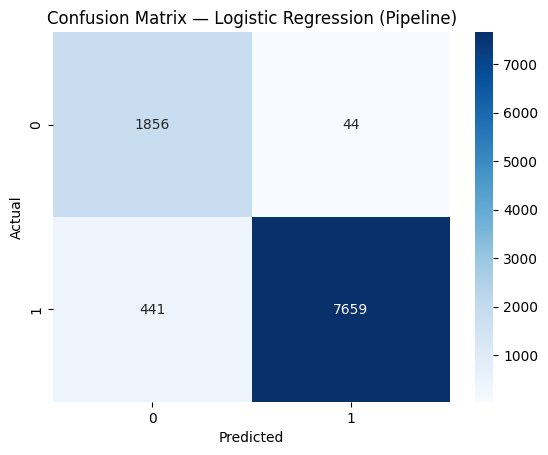

In [14]:
y_pred = logreg_pipeline.predict(X_test)

# Accuracy & Classification Report
accuracy = accuracy_score(y_test, y_pred)
print("\n================ RESULTS ================")
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression (Pipeline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


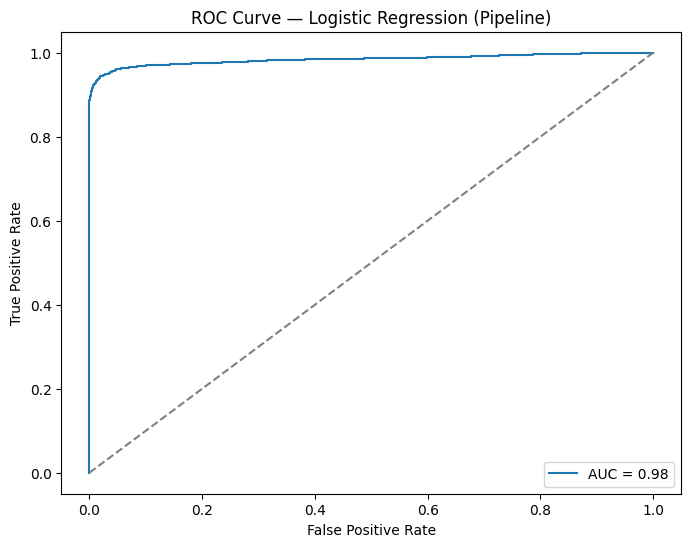

In [15]:
y_prob = logreg_pipeline.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Pipeline)")
plt.legend()
plt.show()


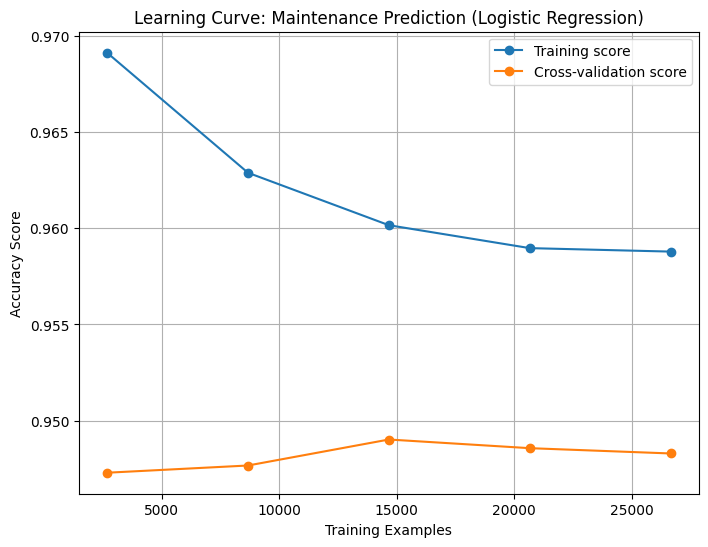

In [16]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    logreg_pipeline,
    X_train,
    y_train,
    cv=3,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="accuracy"
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Cross-validation score")
plt.title("Learning Curve: Maintenance Prediction (Logistic Regression)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [32]:
X_test_subset = X_test.iloc[:subset_size]

# Keep only numeric columns
X_test_subset = X_test_subset.select_dtypes(include=["number"])


In [33]:
X_embedded = tsne.fit_transform(X_test_subset)


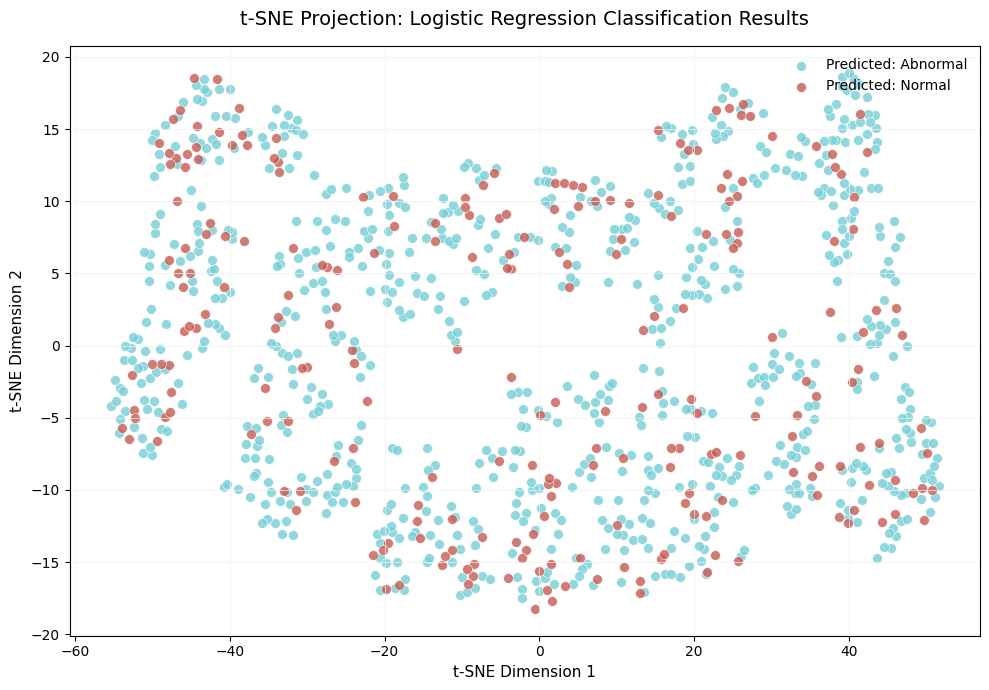

In [35]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Run t-SNE on the TEST data (since that's what we predicted on)
# We use the data from the pipeline (X_test)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# Taking a subset of 1000 for performance if your test set is large
subset_size = 1000


# 2. Setup the plot style
plt.figure(figsize=(10, 7))
plt.rcParams['axes.facecolor'] = 'white'

# Colors for the PREDICTED classes
# Teal for Predicted Abnormal, Muted Red for Predicted Normal
colors = {1: '#76ced6', 0: '#c55a51'}
labels = {1: 'Predicted: Abnormal', 0: 'Predicted: Normal'}

# 3. Plot based on what the Logistic Regression CLASSIFIED
for target_class in [1, 0]:
    mask = (y_pred_subset == target_class)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        c=colors[target_class],
        label=labels[target_class],
        alpha=0.8,
        edgecolors='white',
        linewidths=0.5,
        s=50
    )

# 4. Final Styling
plt.title("t-SNE Projection: Logistic Regression Classification Results", fontsize=14, pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

plt.grid(True, color='#f0f0f0', linestyle='-', linewidth=0.5)
plt.legend(frameon=False, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()